In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_path = r"D:\Dataset\Anmol-MP-EV"

processed_path = os.path.join(base_path, "processed_data")
figure_path = os.path.join(base_path, "figures")

print("TOU analysis environment loaded")

TOU analysis environment loaded


In [2]:
tou_data = pd.read_csv(
    os.path.join(
        processed_path,
        "TOU_response_all_stations.csv"
    )
)

tou_data.head()

,TOU_period,mean,max,sum,Station
0,Off-peak,360.881880,1688.9,4238196.8,A1
1,Peak,115.655767,753.6,1018696.0,A1
2,Shoulder,287.893713,1413.2,4226279.7,A1
3,Off-peak,1008.384077,3020.3,11842462.6,A2
4,Peak,310.047446,911.2,2730897.9,A2


In [3]:
print(tou_data.columns.tolist())

['TOU_period', 'mean', 'max', 'sum', 'Station']


In [4]:
tou_data.head()

,TOU_period,mean,max,sum,Station
0,Off-peak,360.881880,1688.9,4238196.8,A1
1,Peak,115.655767,753.6,1018696.0,A1
2,Shoulder,287.893713,1413.2,4226279.7,A1
3,Off-peak,1008.384077,3020.3,11842462.6,A2
4,Peak,310.047446,911.2,2730897.9,A2


In [5]:
import matplotlib.pyplot as plt

# Calculate average response across all stations
tou_avg = (
    tou_data
    .groupby("TOU_period")["mean"]
    .mean()
    .reset_index()
)

tou_avg

,TOU_period,mean
0,Off-peak,935.223325
1,Peak,125.827965
2,Shoulder,231.418107


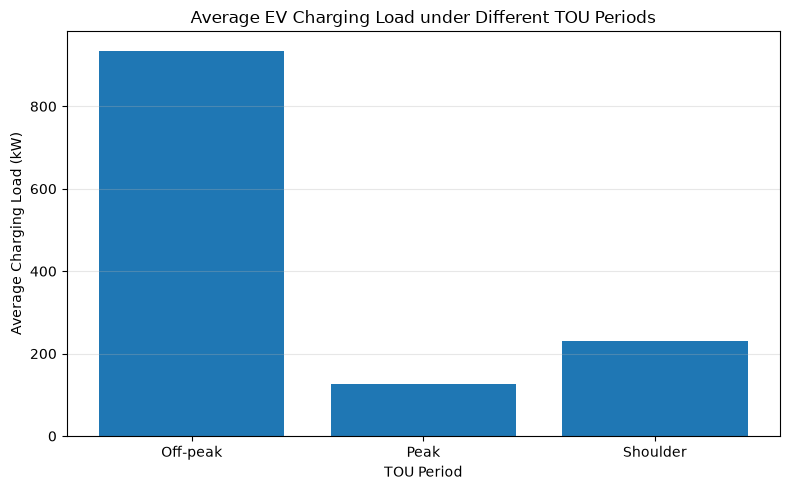

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    tou_avg["TOU_period"],
    tou_avg["mean"]
)

plt.title("Average EV Charging Load under Different TOU Periods")
plt.xlabel("TOU Period")
plt.ylabel("Average Charging Load (kW)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\TOU_average_load_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
tou_station = (
    tou_data
    .pivot(
        index="Station",
        columns="TOU_period",
        values="mean"
    )
    .reset_index()
)

tou_station

TOU_period,Station,Off-peak,Peak,Shoulder
0,A1,360.881880,115.655767,287.893713
1,A10,355.069233,23.907732,102.491340
2,A2,1008.384077,310.047446,625.868093
3,A3,1554.345172,37.623104,117.854605
4,A4,3540.455569,57.364373,106.859060
5,A5,15.336981,4.676010,4.193270
6,A6,34.961121,25.567950,16.777616
7,A9,612.352572,431.781335,589.407159


<Figure size 1200x600 with 0 Axes>

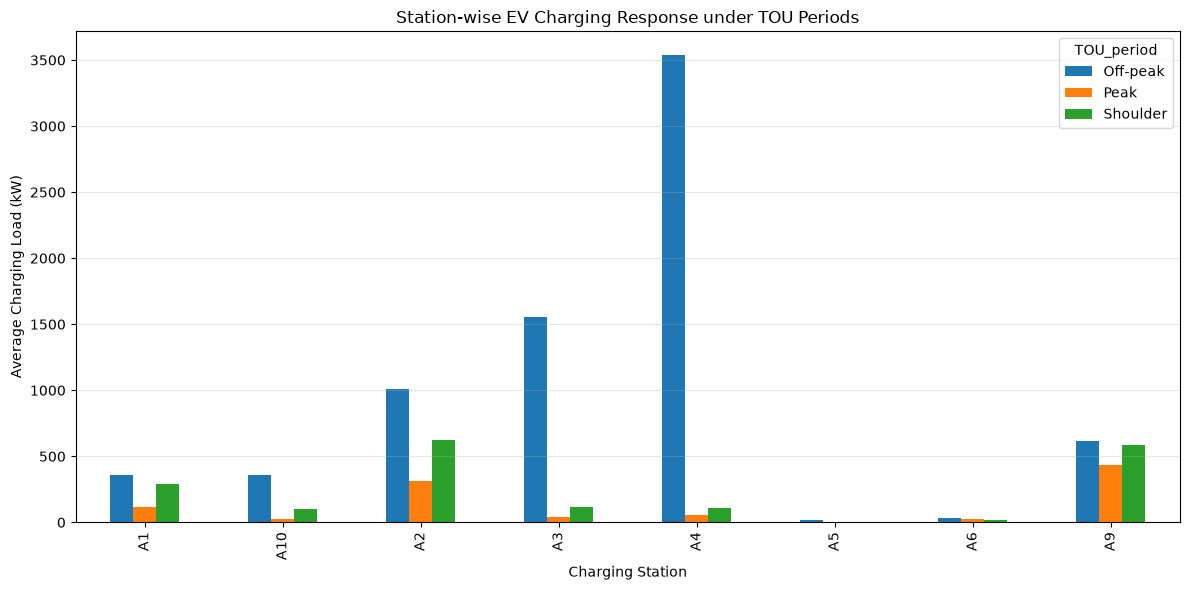

In [8]:
plt.figure(figsize=(12,6))

tou_station.set_index("Station").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Station-wise EV Charging Response under TOU Periods")
plt.xlabel("Charging Station")
plt.ylabel("Average Charging Load (kW)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\TOU_station_response_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
tou_station = (
    tou_data
    .pivot(
        index="Station",
        columns="TOU_period",
        values="mean"
    )
    .reset_index()
)

tou_station

TOU_period,Station,Off-peak,Peak,Shoulder
0,A1,360.881880,115.655767,287.893713
1,A10,355.069233,23.907732,102.491340
2,A2,1008.384077,310.047446,625.868093
3,A3,1554.345172,37.623104,117.854605
4,A4,3540.455569,57.364373,106.859060
5,A5,15.336981,4.676010,4.193270
6,A6,34.961121,25.567950,16.777616
7,A9,612.352572,431.781335,589.407159


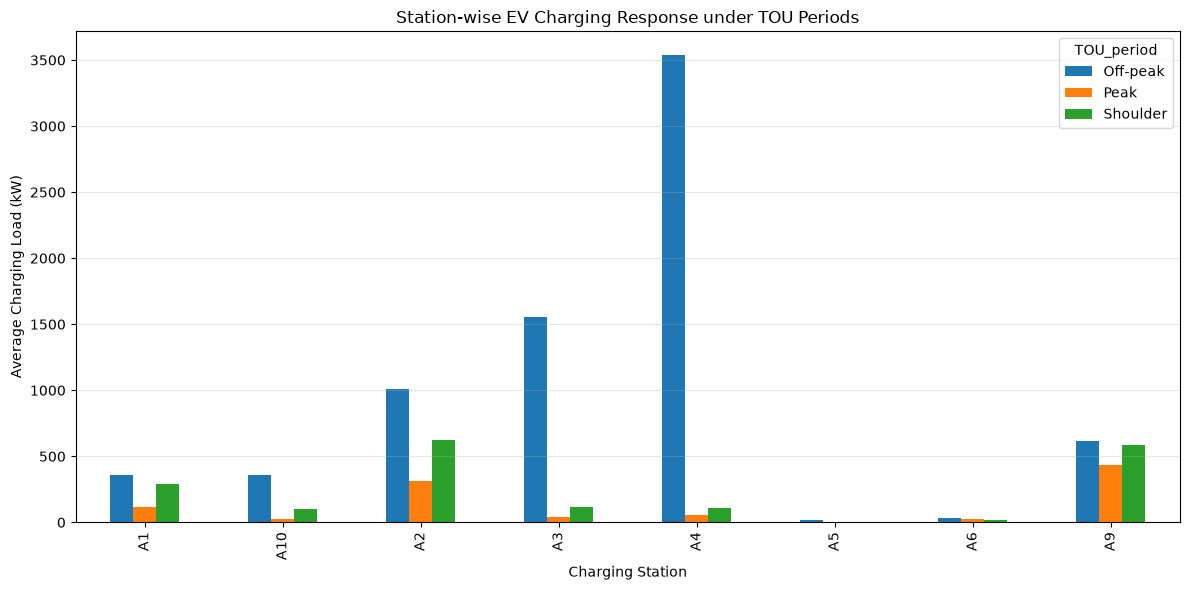

In [10]:
import matplotlib.pyplot as plt

tou_station_plot = tou_station.set_index("Station")

tou_station_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Station-wise EV Charging Response under TOU Periods")
plt.xlabel("Charging Station")
plt.ylabel("Average Charging Load (kW)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\TOU_station_response_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
peak_avoidance = tou_station.copy()

peak_avoidance["Peak_Avoidance_Ratio_%"] = (
    (peak_avoidance["Off-peak"] - peak_avoidance["Peak"])
    /
    peak_avoidance["Off-peak"]
    * 100
)

peak_avoidance

TOU_period,Station,Off-peak,Peak,Shoulder,Peak_Avoidance_Ratio_%
0,A1,360.881880,115.655767,287.893713,67.951905
1,A10,355.069233,23.907732,102.491340,93.266741
2,A2,1008.384077,310.047446,625.868093,69.253040
3,A3,1554.345172,37.623104,117.854605,97.579488
4,A4,3540.455569,57.364373,106.859060,98.379746
5,A5,15.336981,4.676010,4.193270,69.511532
6,A6,34.961121,25.567950,16.777616,26.867477
7,A9,612.352572,431.781335,589.407159,29.488116


In [12]:
peak_avoidance.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\peak_avoidance_ratio.csv",
    index=False
)

print("Peak avoidance results saved")

Peak avoidance results saved


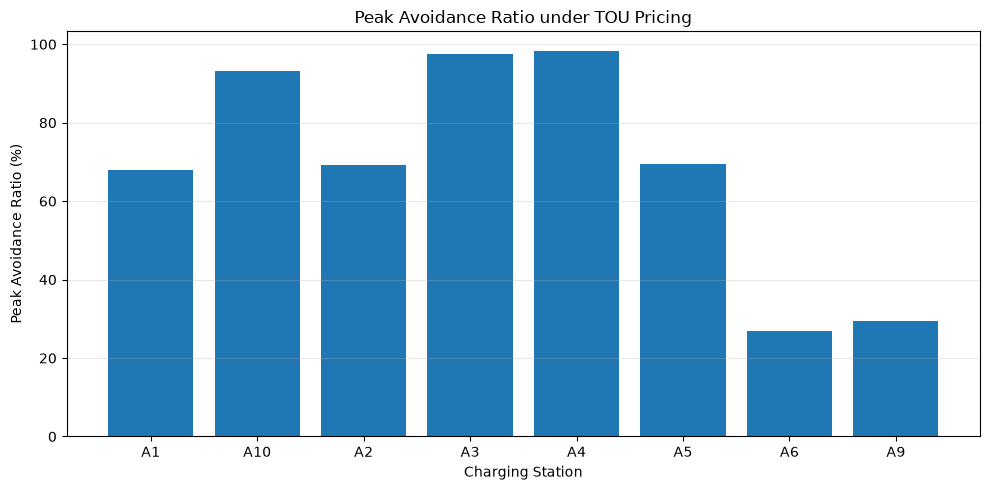

In [13]:
plt.figure(figsize=(10,5))

plt.bar(
    peak_avoidance["Station"],
    peak_avoidance["Peak_Avoidance_Ratio_%"]
)

plt.title("Peak Avoidance Ratio under TOU Pricing")
plt.xlabel("Charging Station")
plt.ylabel("Peak Avoidance Ratio (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\peak_avoidance_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()